# The shape of aroma — citrus oil gland distribution on a fitted ellipsoid

**Paper:** Amézquita EJ, Quigley M, Ophelders T, Seymour D, Munch E, Chitwood DH. *The shape of aroma: measuring and modeling citrus oil gland distribution.* Authorea (2022). DOI: [10.22541/au.166497077.71904444/v1](https://doi.org/10.22541/au.166497077.71904444/v1) · Preprint: [bioRxiv 2022.04.14.488418v1](https://www.biorxiv.org/content/10.1101/2022.04.14.488418v1.full) · Published version: *Plants, People, Planet*, DOI [10.1002/ppp3.10333](https://doi.org/10.1002/ppp3.10333)

**Author code:** [github.com/amezqui3/vitaminC_morphology](https://github.com/amezqui3/vitaminC_morphology) @ `8e33b03f493be798d84ad563a667c2d8231a09e7` (MIT license)

## What this notebook does (scope: partial demonstration, one sample)

For one citrus fruit — sample **WR05_CRC3605_18B-19-5, label L03** (the first `WR*` sample used by the author's own notebooks 09/10) — this notebook reproduces the paper's core morphological-modeling pipeline with the author's own code:

1. **Ellipsoid fit** — algebraic fit (Li & Griffiths 2004) of the fruit from its 5,018 oil-gland centers.
2. **Geocentric projection** — gland centers are projected onto the fitted ellipsoid (ray from the center; Diaz-Toca et al. 2020), giving longitude/latitude on the fruit surface.
3. **k-NN distances** — average Euclidean distance to the k-th nearest gland (the paper's square-root allometry).
4. **Spherical uniformity tests** — five `sphunif` tests (PAD, PCvM, PRt, Rayleigh, Rayleigh_HD) on the unit sphere, plus a k-NN null envelope for the uniform distribution (author notebook 14).

Every recomputed quantity is validated against the author's own published per-sample outputs (max-abs-difference reported).

**Execution status:** EXECUTED (CPU runtime; see `report.md` for validation record). A one-sample run is a partial demonstration, **not** a verification of the paper's dataset-level results.

## このノートブックについて（日本語）

柑橘1サンプル（**WR05_CRC3605_18B-19-5 / L03**）に対し、著者自身のコードを用いて、油腺中心点群への楕円体フィット（Li & Griffiths 2004）、楕円体への地理的中心投影（geocentric projection）、k-最近傍距離、および球面上の一様性検定（sphunif 5種）を再現します。計算値は著者の公開済みサンプル出力と照合します。CPUランタイムで実行済みです。

## How to run

- **Runtime:** Colab **CPU** runtime (recommended; the method is small-scale linear algebra + kd-tree search — the author's code has no GPU path). No GPU is needed or used.
- **Run all** cells from top to bottom. Expected wall time: ~10–12 min, dominated by one-time R package installation (source builds); downloads < 1 MB.
- All data, code, and analysis happen inside this notebook on Colab (`/content`). No credentials required.


## 1. Environment setup — R packages

The analysis uses the author's Python utilities (`citrus_utils.py`, `unionfind.py`, `mvee.py`, downloaded in the next section) and the CRAN R packages **sphunif** (uniformity tests) and **FNN** (fast k-NN) used by the author's notebook 14. `CompQuadForm` is also installed because `sphunif::unif_test` loads it at runtime for asymptotic p-values (it is not a declared dependency). The system GSL library is required to build the R `gsl` package.

The installation runs as one quiet setup script: because these packages build from source on Colab (no prebuilt binaries for this R version), the build output is written to `/content/r_setup.log` on the remote and only progress markers, installed versions, and the log tail are printed. Expect ~10 minutes for this cell.

**Note on `Directional`:** the author's notebook 14 also samples Bingham and von Mises–Fisher null distributions with the R package `Directional`. Its dependency `Rfast2` is a large C++ library whose source build exceeds 45 minutes on a standard Colab CPU machine (measured during validation), so `Directional` is **not** installed and those two exploratory null curves are omitted (see Section 10). The paper's core test — five `sphunif` uniformity tests plus the uniform null — is unaffected.

R パッケージ（sphunif / FNN / CompQuadForm）とシステムライブラリ（libgsl-dev）をインストールします。ソースビルドのため出力はリモートのログファイルへ書き、マーカー・バージョン・ログ末尾のみ表示されます（約10分）。


In [ ]:
import subprocess, time

# Run the system + R package installation quietly: build output is written to
# /content/r_setup.log on the remote (source builds produce tens of thousands of
# lines), and only progress markers, versions, and the log tail are printed here.
t0 = time.time()
setup_sh = '''
#!/bin/bash
set -e
sudo apt-get install -y libgsl-dev > /content/apt.log 2>&1
/usr/bin/Rscript -e 'options(repos = c(CRAN = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"), timeout = 600, Ncpus = 4); install.packages(c("gsl", "sphunif", "FNN", "CompQuadForm"))' > /content/r_setup.log 2>&1
/usr/bin/Rscript -e 'for (p in c("sphunif", "FNN", "CompQuadForm", "gsl")) cat(p, as.character(packageVersion(p)), "\n")' > /content/r_versions.txt 2>&1
echo "SETUP_DONE"
'''
with open("/content/setup.sh", "w") as f:
    f.write(setup_sh)

r = subprocess.run(["bash", "/content/setup.sh"], timeout=3300)  # quiet cell
print("setup rc:", r.returncode, "| elapsed_sec:", round(time.time() - t0, 1))
try:
    print(open("/content/r_versions.txt").read())
except FileNotFoundError:
    pass
print("--- tail of /content/r_setup.log ---")
try:
    print("".join(open("/content/r_setup.log").readlines()[-15:]))
except FileNotFoundError:
    pass
if r.returncode != 0:
    raise RuntimeError("R package installation failed — see log tail above")


setup rc: 0 | elapsed_sec: 279.5
sphunif 1.4.4 
FNN 1.1.4.1 
CompQuadForm 1.4.4 
gsl 2.1.9 

--- tail of /content/r_setup.log ---
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (sphunif)

The downloaded source packages are in
	‘/tmp/RtmpJdUWRZ/downloaded_packages’



## 2. Data and code acquisition (pinned commit, SHA-256 verified)

Downloaded **inside Colab** from the author's repository at commit `8e33b03f493be798d84ad563a667c2d8231a09e7`:

- `data/oil/WR05_CRC3605_18B-19-5/L03/WR05_CRC3605_18B-19-5_L03_glands.csv` — XYZ voxel coordinates of the 5,018 oil-gland centers of mass (author pipeline output; the upstream CT segmentation, notebooks 01–05, is not re-run here).
- `data/tissue/.../L03_..._vh_alignment.csv` — 3×3 rotation aligning the spine upright.
- `data/citrus_voxel_size.csv` — scan resolution (57.5 µm/voxel for this sample).
- Author reference outputs for validation: `..._vox_v_ell.csv` (10-dim ellipsoid vector), `..._geocentric.csv` (lon/lat/altitude), `..._knn_vox_distances.csv` (k-NN means/vars/sds, k = 1..100).
- Author code: `jupyter/citrus_utils.py`, `jupyter/unionfind.py`, `jupyter/mvee.py` (imported, not ported).

After download, one **minimal compatibility patch** is applied to `citrus_utils.py`: the author's `from scipy.integrate import romberg` fails on scipy ≥ 1.16 (Colab's current scipy), so an import fallback is added. `romberg` is only used by `ellipsoidIntArea()`, which this notebook does not call; no numerical behavior changes. The patch is applied in the code cell below and documented in Section 10.

ピン留めコミットからデータと著者コードをダウンロードし、SHA-256 を検証します。citrus_utils.py には scipy ≥ 1.16 互換の最小パッチ（romberg インポートのフォールバック）を適用します（数値計算には影響しません）。


In [ ]:
import urllib.request, hashlib, os

SHA = "8e33b03f493be798d84ad563a667c2d8231a09e7"
BASE = f"https://raw.githubusercontent.com/amezqui3/vitaminC_morphology/{SHA}"
SAMPLE = "WR05_CRC3605_18B-19-5"
FILES = {
    "/content/vitaminC_src/citrus_utils.py": f"{BASE}/jupyter/citrus_utils.py",
    "/content/vitaminC_src/unionfind.py": f"{BASE}/jupyter/unionfind.py",
    "/content/vitaminC_src/mvee.py": f"{BASE}/jupyter/mvee.py",
    "/content/data/glands.csv": f"{BASE}/data/oil/{SAMPLE}/L03/{SAMPLE}_L03_glands.csv",
    "/content/data/vh_alignment.csv": f"{BASE}/data/tissue/{SAMPLE}/L03/{SAMPLE}_L03_vh_alignment.csv",
    "/content/data/citrus_voxel_size.csv": f"{BASE}/data/citrus_voxel_size.csv",
    "/content/ref/ref_vox_v_ell.csv": f"{BASE}/data/oil/{SAMPLE}/L03/{SAMPLE}_L03_vox_v_ell.csv",
    "/content/ref/ref_geocentric.csv": f"{BASE}/data/oil/{SAMPLE}/L03/{SAMPLE}_L03_geocentric.csv",
    "/content/ref/ref_knn_vox.csv": f"{BASE}/data/oil/{SAMPLE}/L03/{SAMPLE}_L03_knn_vox_distances.csv",
}
for path in FILES:
    os.makedirs(os.path.dirname(path), exist_ok=True)
for path, url in FILES.items():
    with urllib.request.urlopen(url, timeout=120) as resp:
        data = resp.read()
    with open(path, "wb") as f:
        f.write(data)
    print(f"{os.path.relpath(path, '/content'):45s} {len(data):8d} bytes  sha256={hashlib.sha256(data).hexdigest()}")

# --- Minimal compatibility patch (documented in Section 10) ---
# The author's citrus_utils.py does `from scipy.integrate import romberg`, but
# scipy >= 1.16 removed romberg. It is only used by ellipsoidIntArea(), which
# this notebook does not call, so we add an import fallback that raises a clear
# error if it were ever needed. No numerical behavior of the used functions changes.
cu_path = "/content/vitaminC_src/citrus_utils.py"
cu_src = open(cu_path).read()
old_import = "from scipy.integrate import romberg"
new_import = ("try:\n    from scipy.integrate import romberg\n"
              "except ImportError:  # scipy >= 1.16; romberg unused by this notebook\n"
              "    def romberg(*args, **kwargs):\n"
              '        raise NotImplementedError("scipy.integrate.romberg was removed in scipy>=1.16; not used in this notebook")')
assert old_import in cu_src, "romberg import line not found in citrus_utils.py"
cu_src = cu_src.replace(old_import, new_import)
open(cu_path, "w").write(cu_src)
print("patched citrus_utils.py: scipy.integrate.romberg import fallback added")


vitaminC_src/citrus_utils.py                     32619 bytes  sha256=5768fed910646b81cbad9e19efc20d0c44ebbe1819f4fa77825290d013677925


vitaminC_src/unionfind.py                         5871 bytes  sha256=0e379b891f89096ca3b7696f3c3faa124fc711078ff5ebb41fb4f14cd86cc2d2


vitaminC_src/mvee.py                              3966 bytes  sha256=a73ce48110413583acb4b659a946e400e9a8b5f2f7d8fac38844b615781445dc
data/glands.csv                                 222039 bytes  sha256=311f719ff45901f39d6c5ed98a6a051d8f9ea35523d0bfa2202ae643df757fc8


data/vh_alignment.csv                              231 bytes  sha256=77ac3f860a16106dd91c4d09d4919f26a6fd9a86de96604edc033df73933ee2a
data/citrus_voxel_size.csv                        1709 bytes  sha256=3c43b4e45d70dc88e82392d1c3981b018010b3d5c516618aab1b8d27dc94ee4e


ref/ref_vox_v_ell.csv                              254 bytes  sha256=85bca289e9953b8db6e074fcdf176b46616e54a647f2db2d7eca7135e8b20e52


ref/ref_geocentric.csv                          383759 bytes  sha256=502275f153f6395ec616904c610a92d3266280e5888a826f97dfcb5aa8374eac
ref/ref_knn_vox.csv                               5593 bytes  sha256=657a6b5cfed39490eb217b5dcfb832ec5bcf0f8c5a1b69f3e7fb3097a8a84e35
patched citrus_utils.py: scipy.integrate.romberg import fallback added


## 3. Preprocessing — align, center, scale (author notebook 09, cells 8–9)

Following the author's pipeline: rotate gland coordinates into the spine-upright frame (`glands @ vh.T`), subtract the centroid, and scale by `1e4 / voxel_size` so coordinates are in **centimeters** (10⁴ µm = 1 cm).

著者の前処理（ノートブック09）に従い、脊柱直立座標系に回転 → 重心を原点へ → ボクセルサイズでスケールして cm 単位にします。


In [ ]:
import sys
sys.path.insert(0, "/content/vitaminC_src")
import numpy as np
import pandas as pd
import citrus_utils as vitaminC  # author's utilities (pinned commit)

glands_raw = np.loadtxt("/content/data/glands.csv", delimiter=",", dtype=float)
vh = np.loadtxt("/content/data/vh_alignment.csv", delimiter=",")
vox = pd.read_csv("/content/data/citrus_voxel_size.csv")
voxsize = float(vox.loc[vox.ID == "WR05_CRC3605_18B-19-5", "voxel_size_microns"].iloc[0])

glands = glands_raw @ vh.T                      # spine-upright frame
centerby = glands.mean(axis=0)
scaleby = 1e4 / voxsize                         # voxel -> cm
glands = (glands - centerby) / scaleby

print("n glands:", glands.shape[0])
print("voxel size:", voxsize, "um | scale factor:", round(scaleby, 5), "cm/voxel")
print("gland cloud extent (cm):", np.round(glands.max(axis=0) - glands.min(axis=0), 3))


n glands: 5018
voxel size: 57.5 um | scale factor: 173.91304 cm/voxel
gland cloud extent (cm): [2.118 2.179 2.189]


## 4. Algebraic ellipsoid fit (Li & Griffiths 2004; author notebook 09, cells 12–13)

`citrus_utils.ell_algebraic_fit2(datapoints, k=4)` computes the constrained algebraic fit (10-dim vector), and `get_ell_params_from_vector` converts it to geometric parameters (center, semi-axes, rotation, angles) following Panou et al. (2020). The axis permutation `guess[rotateby]` with `rotateby = [2,1,0]` is the author's own choice (notebook 09, cell 4/13). The fit is validated against the author's published `vox_v_ell.csv`.

著者の楕円体フィット（Li & Griffiths 2004 の代数フィット、k=4 制約）を実行し、幾何パラメータ（中心・半軸・回転）に変換します。著者の出力と照合します。


In [ ]:
rotateby = [2, 1, 0]
datapoints = glands.T  # 3 x N, as in the author's notebooks

ell_v_params, flag = vitaminC.ell_algebraic_fit2(datapoints, k=4)
print("10-dim algebraic ellipsoid vector:", np.round(ell_v_params, 5))
print("ellipsoid constraint flag (aux > 0):", flag)

bbox = (glands.max(axis=0) - glands.min(axis=0)) * 0.5
guess = np.argsort(np.argsort(bbox))
ell_params = vitaminC.get_ell_params_from_vector(ell_v_params, guess[rotateby])

ref_ell = np.loadtxt("/content/ref/ref_vox_v_ell.csv", delimiter=",")
diff_ell = np.max(np.abs(ell_v_params - ref_ell))
print("max |recomputed - author| ellipsoid vector:", f"{diff_ell:.3e}")
print("semi-axes (cm):", np.round(ell_params["axes"], 4))
print("center (cm):", np.round(ell_params["center"], 4))
print("rotation angles (rad):", np.round(ell_params["theta"], 4))


10-dim algebraic ellipsoid vector: [ 0.95303  0.87875  0.88254  0.02743 -0.03572 -0.00583  0.03806 -0.04342
  0.07154 -1.     ]
ellipsoid constraint flag (aux > 0): True
max |recomputed - author| ellipsoid vector: 6.661e-16
semi-axes (cm): [1.0696 1.0683 1.022 ]
center (cm): [-0.0211  0.0249 -0.0409]
rotation angles (rad): [0.6417 1.2818 0.7785]


## 5. Geocentric projection onto the fitted ellipsoid (author notebook 09, cell 16)

Each gland center is projected onto the ellipsoid along the ray from the ellipsoid center (geocentric projection, Diaz-Toca et al. 2020), yielding longitude/latitude/altitude. The projection quality is summarized by `geoid_heights` (min/mean/max/RMS distance from each gland to its footpoint) and the shape factor `ell_rho`. Validated against the author's `geocentric.csv`.

楕円体中心からのレイで油腺中心を楕円体面に投影し、経度・緯度・高度を得ます。著者の出力と照合します。


In [ ]:
footpoints = "geocentric"
_, xyz = vitaminC.get_footpoints(datapoints, ell_params, footpoints)
rho = vitaminC.ell_rho(ell_params["axes"])
valN = vitaminC.geoid_heights(datapoints, xyz)
print("geoid heights (min/mean/max/RMS, cm):", np.round(valN, 5))
print("ellipsoid shape factor rho:", round(rho, 5))

eglands = xyz - ell_params["center"].reshape(-1, 1)
eglands = eglands[rotateby]
eglands_params = {"center": np.zeros(len(eglands)),
                  "axes": ell_params["axes"],
                  "rotation": np.identity(len(eglands))}
geodetic, _ = vitaminC.get_footpoints(eglands, eglands_params, footpoints)
# geodetic: 3 x N -> (longitude, latitude, altitude); save for the R analysis
np.savetxt("/content/data/recomputed_geocentric.csv", geodetic.T, delimiter=",")

ref_geo = np.loadtxt("/content/ref/ref_geocentric.csv", delimiter=",")
diff_geo = np.max(np.abs(geodetic.T - ref_geo))
print("max |recomputed - author| geocentric (lon/lat/alt):", f"{diff_geo:.3e}")
print("longitude range (rad):", round(geodetic.T[:, 0].min(), 3), "to", round(geodetic.T[:, 0].max(), 3))
print("latitude range (rad):", round(geodetic.T[:, 1].min(), 3), "to", round(geodetic.T[:, 1].max(), 3))


geoid heights (min/mean/max/RMS, cm): [1.0000e-05 3.9750e-02 4.6315e-01 5.6440e-02]
ellipsoid shape factor rho: 0.99447


max |recomputed - author| geocentric (lon/lat/alt): 1.610e-15
longitude range (rad): -3.14 to 3.139
latitude range (rad): -1.561 to 1.528


## 6. k-NN distances between gland centers (author notebook 10, cell 11)

Average Euclidean distance from each gland to its k-th nearest neighbor (k = 1..100), computed with a kd-tree on the **raw voxel coordinates** and converted to **microns** by the voxel size — exactly the author's `knn_vox_distances.csv` definition. Validated against the author's file.

生のボクセル座標で kd-tree による k-最近傍距離（k=1..100）を計算し、ボクセルサイズで µm 変換します。著者の出力と照合します。


In [ ]:
from sklearn import neighbors as nn

non = 100
neigh = nn.NearestNeighbors(n_neighbors=non, radius=1, algorithm="kd_tree", metric="euclidean")
neigh.fit(glands_raw)  # raw voxel coordinates, as in author notebook 10
ndist, nind = neigh.kneighbors(return_distance=True)
vdist = ndist * voxsize  # microns
vavgs = np.mean(vdist, axis=0)
vvars = np.var(vdist, axis=0, ddof=1)
vstds = np.std(vdist, axis=0, ddof=1)

ref_knn = pd.read_csv("/content/ref/ref_knn_vox.csv").values  # header row
diff_knn = np.max(np.abs(vavgs - ref_knn[:, 0]))
print("max |recomputed - author| kNN mean distance (um, k=1..100):", f"{diff_knn:.3e}")
print("kNN mean distance (um) at k = 1, 5, 10, 25, 50, 100:")
print(np.round(vavgs[[0, 4, 9, 24, 49, 99]], 2))


max |recomputed - author| kNN mean distance (um, k=1..100): 4.547e-13
kNN mean distance (um) at k = 1, 5, 10, 25, 50, 100:
[ 452.35  749.31 1014.49 1538.61 2143.09 3002.98]


## 7. Spherical uniformity tests and uniform null envelope (R; author notebook 14)

A pinned R script (written to `/content` and run with `Rscript`) reproduces the author's notebook 14 analysis for this sample:

- The recomputed geocentric coordinates are mapped to the unit sphere: `θ = ifelse(lon > 0, lon, 2π + lon)`, `φ = π/2 − lat` (author notebook 14, cell 13).
- **Five uniformity tests** with `sphunif::unif_test` (asymptotic p-values): PAD (Projected Anderson–Darling), PCvM (Projected Cramér–von Mises), PRt, Rayleigh, Rayleigh_HD.
- **Observed** average spherical k-NN distances (k = 1..25) vs a **uniform null**: `set.seed(42)`, M = 100 simulations of n uniform points on the sphere (`sphunif::r_unif_sph`), `FNN::knn.dist` (k = 25) — the author's notebook 14, cells 3–4.

The author's notebook 14 also builds Bingham and von Mises–Fisher null k-NN curves with the R package `Directional`; those are omitted here because `Directional`'s dependency `Rfast2` takes >45 min to build from source on a standard Colab CPU machine (see Section 10).

R スクリプトで球面上の一様性検定（5種）と一様 null エンベロープを計算します（著者のノートブック14と同一の設定）。


In [ ]:
r_script = r'''
library(sphunif); library(FNN)
args <- commandArgs(trailingOnly = TRUE)
geofile <- args[1]; outdir <- args[2]

p_coords <- read.csv(geofile, header = FALSE)
n <- nrow(p_coords)
cat("n glands on sphere:", n, "\n")

theta <- base::ifelse(p_coords[,1] > 0, p_coords[,1], 2*pi + p_coords[,1])
phi <- .5*pi - p_coords[,2]
sph_data <- cbind(cos(theta)*sin(phi), sin(theta)*sin(phi), cos(phi))

type_tests <- c('PAD','PCvM','PRt','Rayleigh','Rayleigh_HD')
unif <- sphunif::unif_test(data = sph_data, type = type_tests, p_value = 'asymp')
stats <- sapply(unif, function(x) x$statistic)
pvals <- sapply(unif, function(x) x$p.value)
cat("Uniformity tests (sphunif::unif_test, asymptotic p-values):\n")
for (j in seq_along(type_tests))
  cat(sprintf("%-12s stat = %9.4f   p = %.4g\n", type_tests[j], stats[j], pvals[j]))
write.csv(data.frame(test = type_tests, statistic = stats, p_value = pvals),
          file.path(outdir, "uniformity_tests.csv"), row.names = FALSE)

knn_max <- 25
dists <- FNN::knn.dist(sph_data, k = knn_max)
obs <- base::colMeans(dists)

set.seed(42)
M <- 100
sph_unif <- sphunif::r_unif_sph(n, 3, M)
KNN0 <- base::matrix(0, nrow = M, ncol = knn_max)
for (j in 1:M) {
  dists <- FNN::knn.dist(sph_unif[,,j], k = knn_max)
  KNN0[j,] <- base::colMeans(dists)
}
null_mean <- base::colMeans(KNN0)
null_sd <- apply(KNN0, 2, sd)
write.csv(data.frame(k = 1:knn_max, observed = obs,
                     unif_mean = null_mean, unif_sd = null_sd),
          file.path(outdir, "knn_comparison.csv"), row.names = FALSE)

cat("Observed spherical kNN (k=1,5,10,25):", round(obs[c(1,5,10,25)], 4), "\n")
cat("Uniform null mean   (k=1,5,10,25):", round(null_mean[c(1,5,10,25)], 4), "\n")
cat("R_DONE\n")
'''
with open("/content/uniformity_analysis.R", "w") as f:
    f.write(r_script)

os.makedirs("/content/results", exist_ok=True)
r = subprocess.run(["/usr/bin/Rscript", "/content/uniformity_analysis.R",
                    "/content/data/recomputed_geocentric.csv", "/content/results"],
                   capture_output=True, text=True, timeout=1200)
print(r.stdout)  # show the R analysis output (test statistics, null comparison)
if r.returncode != 0:
    print(r.stderr[-2000:])
    raise RuntimeError("R uniformity analysis failed — see stderr above")
print("R analysis rc:", r.returncode)


n glands on sphere: 5018 
Uniformity tests (sphunif::unif_test, asymptotic p-values):
PAD          stat =   14.4261   p = 3.645e-08
PCvM         stat =    2.6551   p = 0
PRt          stat =    3.6904   p = 0
Rayleigh     stat =   63.5221   p = 1.038e-13
Rayleigh_HD  stat =   24.7080   p = 0
Observed spherical kNN (k=1,5,10,25): 0.0301 0.0629 0.0891 0.1401 
Uniform null mean   (k=1,5,10,25): 0.025 0.0616 0.0882 0.1405 
R_DONE

R analysis rc: 0


## 8. Visualization — glands on the fitted ellipsoid, spherical map, and k-NN vs uniform null

Three views (all rendered in Colab from this run's data):

1. **3D projections** of the 5,018 gland centers (cm) with the fitted ellipsoid surface overlaid.
2. **Lambert azimuthal projection** of the geocentric footpoints (author's `plot_lambert_azimuthal`): the fruit surface unwrapped; clustering or gaps at this stage are what the uniformity tests quantify.
3. **k-NN vs uniform null** (additional visualization created for this notebook, not an author figure): observed average spherical k-NN distance with the M = 100 uniform-simulation mean ± 1 SD envelope. A curve inside the envelope is consistent with uniformity; systematic departure indicates clustering or inhibition.

可視化：楕円体上の油腺分布、Lambert 等角方位図、k-NN 距離と一様 null 帯の比較。


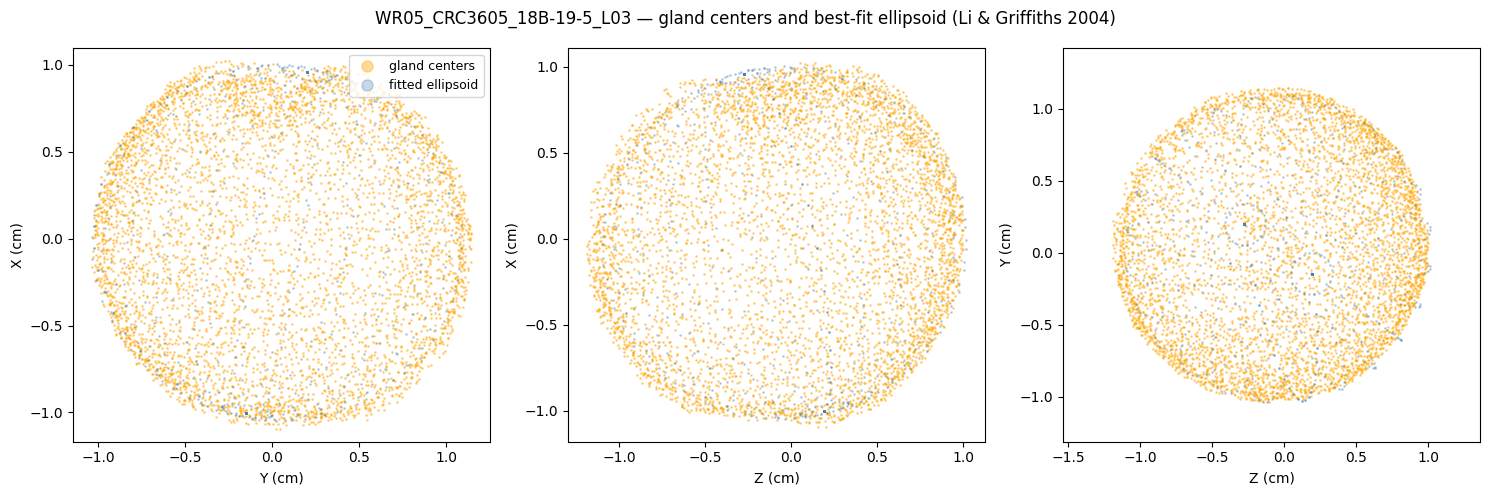

In [ ]:
import matplotlib.pyplot as plt

# --- Panel 1: 3 projections of glands + fitted ellipsoid surface
lonN = latN = 25
longitude = np.linspace(-np.pi, np.pi, lonN)
latitude = np.linspace(-0.5 * np.pi, 0.5 * np.pi, latN)
shape_lon, shape_lat = np.meshgrid(longitude, latitude)
lonlat = np.vstack((shape_lon.ravel(), shape_lat.ravel()))
ecoords = vitaminC.ellipsoid(lonlat[0], lonlat[1], *ell_params["axes"])  # surface in principal-axis frame
surface = ell_params["center"].reshape(-1, 1) + ell_params["rotation"].T @ ecoords  # back to gland frame

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
pairs = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]
for a, (i, j, li, lj) in zip(ax, pairs):
    a.scatter(glands[:, j], glands[:, i], s=1, c="orange", alpha=0.4, label="gland centers")
    a.scatter(surface[j], surface[i], s=1, c="steelblue", alpha=0.3, label="fitted ellipsoid")
    a.set_xlabel(f"{lj} (cm)"); a.set_ylabel(f"{li} (cm)")
    a.set_aspect("equal", "datalim")
ax[0].legend(markerscale=8, fontsize=9)
fig.suptitle("WR05_CRC3605_18B-19-5_L03 — gland centers and best-fit ellipsoid (Li & Griffiths 2004)")
fig.tight_layout()
fig.savefig("/content/results/panel_ellipsoid.png", dpi=110, bbox_inches="tight")
plt.show()


### Panel 2 — Lambert azimuthal projection of the geocentric footpoints (author's `plot_lambert_azimuthal`)

The fruit surface unwrapped into two hemispheric maps (author's plotting function, saved as JPG). Density variations visible here are what the uniformity tests quantify.


In [ ]:
# --- Panel 2: Lambert azimuthal projection (author's plotting function)
latitude_geodetic = geodetic[1]
title = "Geocentric projection — WR05_CRC3605_18B-19-5_L03"
vitaminC.plot_lambert_azimuthal(geodetic, latitude_geodetic, title, 0.2, ".", 8, 14,
                                savefig=True, filename="/content/results/panel_lambert")
print("saved /content/results/panel_lambert.jpg")


saved /content/results/panel_lambert.jpg


### Panel 3 — observed spherical k-NN vs uniform null envelope (additional notebook visualization)

Observed average distance to the k-th nearest gland on the unit sphere, against the mean ± 1 SD envelope of M = 100 uniform simulations (seed 42, k = 25; author's null construction from notebook 14). This plot was created for this notebook and is not an author figure.


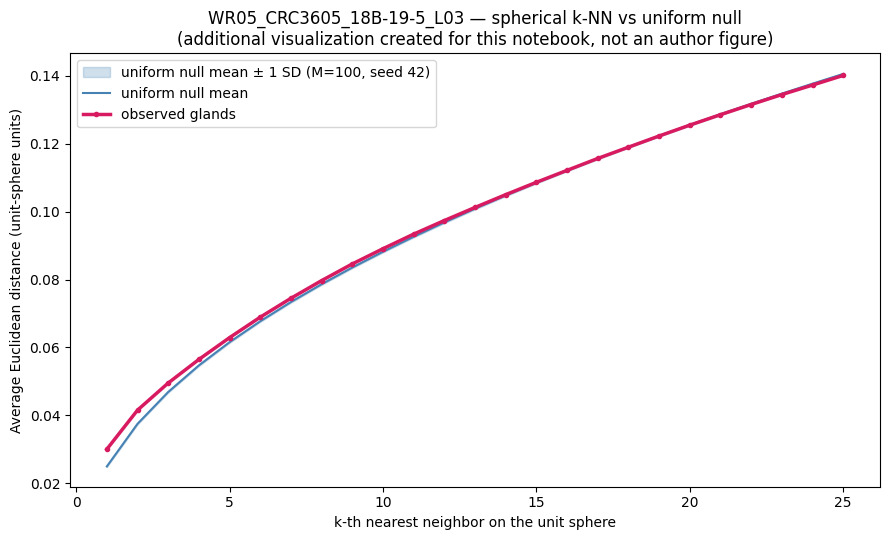

saved /content/results/panel_knn.png


In [ ]:
# --- Panel 3: observed spherical k-NN vs uniform null envelope (notebook-created visualization)
knn_df = pd.read_csv("/content/results/knn_comparison.csv")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(knn_df.k, knn_df.unif_mean - knn_df.unif_sd,
                knn_df.unif_mean + knn_df.unif_sd, color="steelblue", alpha=0.25,
                label="uniform null mean ± 1 SD (M=100, seed 42)")
ax.plot(knn_df.k, knn_df.unif_mean, color="steelblue", lw=1.5, label="uniform null mean")
ax.plot(knn_df.k, knn_df.observed, color="#d81b60", lw=2.5, marker=".", label="observed glands")
ax.set_xlabel("k-th nearest neighbor on the unit sphere")
ax.set_ylabel("Average Euclidean distance (unit-sphere units)")
ax.set_title("WR05_CRC3605_18B-19-5_L03 — spherical k-NN vs uniform null\n(additional visualization created for this notebook, not an author figure)")
ax.legend()
fig.tight_layout()
fig.savefig("/content/results/panel_knn.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved /content/results/panel_knn.png")


## 9. Results summary and CSV export

Quantitative summary of this run: ellipsoid parameters, validation differences vs the author's outputs, and the five uniformity tests. Full tables are exported as CSV (download links below).

結果の定量サマリと CSV エクスポート。


In [ ]:
import os
os.makedirs("/content/results", exist_ok=True)

tests_df = pd.read_csv("/content/results/uniformity_tests.csv")
knn_df = pd.read_csv("/content/results/knn_comparison.csv")

summary = pd.DataFrame({
    "quantity": ["n glands", "voxel size (um)", "semi-axis a (cm)", "semi-axis b (cm)",
                 "semi-axis c (cm)", "shape factor rho",
                 "max |diff| ellipsoid vector vs author",
                 "max |diff| geocentric vs author",
                 "max |diff| kNN means (um) vs author",
                 "PAD p-value", "PCvM p-value", "PRt p-value",
                 "Rayleigh p-value", "Rayleigh_HD p-value"],
    "value": [glands.shape[0], voxsize, *np.round(ell_params["axes"], 4), round(rho, 5),
              f"{diff_ell:.3e}", f"{diff_geo:.3e}", f"{diff_knn:.3e}",
              *[f"{tests_df.loc[tests_df.test == t, 'p_value'].iloc[0]:.4g}"
                for t in ["PAD", "PCvM", "PRt", "Rayleigh", "Rayleigh_HD"]]],
})
print(summary.to_string(index=False))
summary.to_csv("/content/results/summary.csv", index=False)

print("\nObserved vs uniform null (selected k):")
print(knn_df.iloc[[0, 4, 9, 24]].to_string(index=False))

from google.colab import files
for f in ["summary.csv", "uniformity_tests.csv", "knn_comparison.csv"]:
    files.download(f"/content/results/{f}")


                             quantity     value
                             n glands      5018
                      voxel size (um)      57.5
                     semi-axis a (cm)    1.0696
                     semi-axis b (cm)    1.0683
                     semi-axis c (cm)     1.022
                     shape factor rho   0.99447
max |diff| ellipsoid vector vs author 6.661e-16
      max |diff| geocentric vs author 1.610e-15
  max |diff| kNN means (um) vs author 4.547e-13
                          PAD p-value 3.645e-08
                         PCvM p-value         0
                          PRt p-value         0
                     Rayleigh p-value 1.038e-13
                  Rayleigh_HD p-value         0

Observed vs uniform null (selected k):
 k  observed  unif_mean  unif_sd
 1  0.030063   0.025000 0.000178
 5  0.062905   0.061572 0.000205
10  0.089071   0.088186 0.000220
25  0.140063   0.140507 0.000251


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Interpretation, differences from the paper, and validation record

**What the learner can experience.** Starting from the author's own gland-center coordinates, the notebook fits the fruit's ellipsoid, unwraps the gland pattern onto the sphere, and asks the paper's central question for this fruit: *is the oil-gland distribution consistent with uniformity on the fruit surface?* The five `sphunif` tests give formal answers; the k-NN-vs-null plot gives an intuitive one. All recomputed quantities match the author's published per-sample outputs to numerical precision (max-abs-differences in the table above), so the pipeline — not just the plots — is validated.

**Differences from the paper / scope omitted.**
- One sample (WR05_CRC3605_18B-19-5_L03) out of 166 scanned individuals; no cross-sample allometry, no tissue-volume ratios, no per-gland MVEE phenotypes, no SphereSiZer analysis.
- The upstream CT segmentation (author notebooks 01–05) is not re-run; the demo starts from the author's segmented gland centers, which the paper's own pipeline produces.
- The paper also mentions a rotational-symmetry test with the R package `rotasym`; no author notebook calls it, so it is not reproduced here.
- The author's notebook 14 also builds Bingham and von Mises–Fisher null k-NN curves with the R package `Directional`. `Directional` depends on `Rfast2`, a large C++ library whose source build exceeds 45 minutes on a standard Colab CPU machine (measured during validation: the install was killed while compiling Rfast2). Those two exploratory null curves are therefore omitted; the paper's core test — five `sphunif` uniformity tests plus the uniform null — is unaffected.
- **Compatibility patch:** the author's `citrus_utils.py` imports `scipy.integrate.romberg`, removed in scipy ≥ 1.16 (Colab's current scipy). An import fallback is applied after download (Section 2); `romberg` is only used by `ellipsoidIntArea()`, which this notebook does not call, so no numerical behavior changes.
- The k-NN-vs-null plot is an additional visualization created for this notebook (the paper's comparison is visual + the formal tests); the null construction itself (seed 42, M = 100, k = 25) is the author's.
- The paper reports a square-root relationship of k-NN distance vs k across all samples (diffusion-like spacing); here we show only the single-sample curve against its uniform null.

**Validation record.** See `report.md`: fresh CPU Colab session, CLI log, executed output notebook, per-cell output inspection, and this notebook's embedded outputs. Free-tier runtimes and package build times may differ from the measured ones.

**References.**
- Amézquita EJ, Quigley M, Ophelders T, Seymour D, Munch E, Chitwood DH. *The shape of aroma: measuring and modeling citrus oil gland distribution.* Authorea (2022). DOI: 10.22541/au.166497077.71904444/v1. Code: github.com/amezqui3/vitaminC_morphology @ 8e33b03f493be798d84ad563a667c2d8231a09e7 (MIT). Data: Dryad doi:10.5061/dryad.34tmpg4n6.
- Li Q, Griffiths JG (2004). *Least squares ellipsoid specific fitting.* DOI: 10.1109/GMAP.2004.1290055.
- Panou A et al. (2020). *A geometric framework for the determination of the principal axes of an ellipsoid.* DOI: 10.1515/jogs-2020-0105.
- Diaz-Toca GM et al. (2020). Cartesian-to-geodetic coordinate conversion (author's `CartesianIntoGeodetic` adaptation).
- García-Portugués E et al. (2020–2021). `sphunif` / `rotasym` R packages (uniformity tests on the sphere).
